In [26]:
paysim_results = project_root / "results"

to_check = [
    ("tabular_full_baseline_none",        "none_model.joblib"),
    ("tabular_full_baseline_class_weight", "class_weight_model.joblib"),  # needs retrain
    ("tabular_full_baseline_smote",        "smote_model.joblib"),
    ("xgb_nofe_none",                      "nofe_none_model.joblib"),
    ("xgb_nofe_weighted",                  "nofe_weighted_model.joblib"),
    ("xgb_nofe_smote",                     "nofe_smote_model.joblib"),
    ("xgb_fe_none",                        "fe_none_model.joblib"),        # needs retrain
    ("xgb_fe_weighted",                    "fe_weighted_model.joblib"),
    ("xgb_fe_smote",                       "fe_smote_model.joblib"),
]

for folder, joblib_name in to_check:
    p = paysim_results / folder / joblib_name
    print(f"{'✓' if p.exists() else '✗ MISSING'}  {folder}/{joblib_name}")

✓  tabular_full_baseline_none/none_model.joblib
✓  tabular_full_baseline_class_weight/class_weight_model.joblib
✓  tabular_full_baseline_smote/smote_model.joblib
✓  xgb_nofe_none/nofe_none_model.joblib
✓  xgb_nofe_weighted/nofe_weighted_model.joblib
✓  xgb_nofe_smote/nofe_smote_model.joblib
✓  xgb_fe_none/fe_none_model.joblib
✓  xgb_fe_weighted/fe_weighted_model.joblib
✓  xgb_fe_smote/fe_smote_model.joblib


In [23]:
import os
p1 = project_root / "results" / "tabular_full_baseline_class_weight"
p2 = project_root / "results" / "xgb_fe_none"
print("class_weight folder exists:", p1.exists())
print("class_weight contents:", list(p1.iterdir()) if p1.exists() else "MISSING")
print("xgb_fe_none folder exists:", p2.exists())
print("xgb_fe_none contents:", list(p2.iterdir()) if p2.exists() else "MISSING")

class_weight folder exists: False
class_weight contents: MISSING
xgb_fe_none folder exists: False
xgb_fe_none contents: MISSING


In [25]:
import json
files = [
    nb_results / "mm_tabular_logreg"        / "A_none"      / "A_none_tuned_test_metrics.json",
    nb_results / "mm_image_efficientnet_b0" / "A_weighted"  / "normal_tuned_metrics.csv",
    nb_results / "mm_deep_efficientnet_b0"  / "C_fe_normal" / "C_fe_normal_tuned_metrics.csv",
]
for f in files:
    if f.exists():
        if f.suffix == ".json":
            print(f"\n{f.parent.name}/{f.name}:", json.load(open(f)))
        else:
            print(f"\n{f.parent.name}/{f.name}:")
            print(pd.read_csv(f))
    else:
        print(f"\nMISSING: {f}")


A_none/A_none_tuned_test_metrics.json: {'threshold': 0.1, 'precision': 0.6245756958587916, 'recall': 1.0, 'f1': 0.768909318846636}

A_weighted/normal_tuned_metrics.csv:
   threshold  precision    recall        f1
0        0.1   0.635409  0.986957  0.773095

C_fe_normal/C_fe_normal_tuned_metrics.csv:
   threshold  precision    recall        f1
0        0.1   0.858879  0.998913  0.923618


# Cost-Ratio Sensitivity and Feasibility Analysis

**Structure:**
- Section 1: Cost-ratio sensitivity (5 ratios: 5:1 → 100:1)
- Section 2: Final comparison at 10:1
- Section 3: Feasibility analysis (Options A, B, C)

**References:** Elkan (2001); Bahnsen et al. (2013); Höppner et al. (2022)


## 0. Setup

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay,
)

sys.path.insert(0, r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src")
from cost_config import FN_WEIGHT, FP_WEIGHT, COST_SCENARIO, ALL_SCENARIOS

%matplotlib inline
plt.rcParams.update({
    "font.family":     "Times New Roman",
    "font.size":        13,
    "axes.titlesize":   13,
    "axes.labelsize":   13,
    "xtick.labelsize":  11,
    "ytick.labelsize":  11,
    "legend.fontsize":  10,
})

PROJECT_ROOT = Path().resolve().parent
R_NB    = PROJECT_ROOT / "notebook" / "results"
FIG_DIR = R_NB / "thesis_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

THRESHOLDS = np.arange(0.01, 1.00, 0.01)
N_LEGIT    = 554
N_FRAUD    = 920

COLOURS = {
    "LR-MM":                "#4C72B0",
    "XGB-MM":               "#55A868",
    "ResNet-18 img-only":   "#DD8452",
    "EfficientNet img-only":"#C44E52",
    "Fusion-ResNet FE":     "#9467BD",
    "Fusion-EffNet FE":     "#E377C2",
    "Fusion-EffNet FE+S":   "#7B2D8B",
}

model_paths = {
    "LR-MM":                R_NB/"mm_tabular_logreg"/"A_none",
    "XGB-MM":               R_NB/"mm_tabular_xgboost"/"B_smote",
    "ResNet-18 img-only":   R_NB/"mm_image_resnet18"/"B_sampler",
    "EfficientNet img-only":R_NB/"mm_image_efficientnet_b0"/"B_sampler",
    "Fusion-ResNet FE":     R_NB/"mm_deep_resnet18"/"C_fe_normal",
    "Fusion-EffNet FE":     R_NB/"mm_deep_efficientnet_b0"/"C_fe_normal",
    "Fusion-EffNet FE+S":   R_NB/"mm_deep_efficientnet_b0"/"D_fe_sampler",
}

print("Active cost scenario:", COST_SCENARIO,
      "  FN weight:", FN_WEIGHT, "  FP weight:", FP_WEIGHT)
print("Test set:", N_FRAUD, "fraud |", N_LEGIT, "legitimate")


Active cost scenario: 10:1   FN weight: 10   FP weight: 1
Test set: 920 fraud | 554 legitimate


## 1. Load test predictions

In [2]:
predictions = {}
for name, folder in model_paths.items():
    p = folder / "test_predictions.csv"
    if p.exists():
        predictions[name] = pd.read_csv(p)
        print("  Loaded:", name, "(", len(predictions[name]), "rows )")
    else:
        print("  MISSING:", name, "—", p)

print("\n" + str(len(predictions)), "models loaded.")


  Loaded: LR-MM ( 1474 rows )
  Loaded: XGB-MM ( 1474 rows )
  Loaded: ResNet-18 img-only ( 1474 rows )
  Loaded: EfficientNet img-only ( 1474 rows )
  Loaded: Fusion-ResNet FE ( 1474 rows )
  Loaded: Fusion-EffNet FE ( 1474 rows )
  Loaded: Fusion-EffNet FE+S ( 1474 rows )

7 models loaded.


## 2. Helper — scan thresholds

In [3]:
def scan_thresholds(y_true, y_prob, model_name,
                    fn_w=FN_WEIGHT, fp_w=FP_WEIGHT):
    rows = []
    for t in THRESHOLDS:
        y_pred = (y_prob >= t).astype(int)
        cm     = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        rows.append({
            "model":         model_name,
            "threshold":     round(t, 2),
            "tn":            int(tn),
            "fp":            int(fp),
            "fn":            int(fn),
            "tp":            int(tp),
            "precision":     float(precision_score(y_true, y_pred,
                                                    zero_division=0)),
            "recall":        float(recall_score(y_true, y_pred,
                                                zero_division=0)),
            "f1":            float(f1_score(y_true, y_pred,
                                            zero_division=0)),
            "alerts":        int(tp + fp),
            "fpr":           fp / max(N_LEGIT, 1),
            "weighted_cost": int(fn * fn_w + fp * fp_w),
        })
    return pd.DataFrame(rows)

def best_at_ratio(scan_df):
    return scan_df.loc[scan_df["weighted_cost"].idxmin()]

# Scan all models once — reused in all sections
all_scans = {}
for name, df in predictions.items():
    all_scans[name] = scan_thresholds(
        df["y_true"].values, df["y_prob"].values, name)

print("Threshold scans complete for", len(all_scans), "models.")


Threshold scans complete for 7 models.


---
## Section 1 — Cost-ratio sensitivity analysis

Tests five FN:FP weight ratios: 5:1, 10:1, 20:1, 50:1, 100:1.
Asks: does the model ranking change? Do models collapse?


In [4]:
sensitivity_rows = []

for name, scan in all_scans.items():
    yt = predictions[name]["y_true"].values
    yp = predictions[name]["y_prob"].values

    for ratio_label, (fn_w, fp_w) in ALL_SCENARIOS.items():
        best_cost = np.inf
        best_row  = None
        for t in THRESHOLDS:
            y_pred = (yp >= t).astype(int)
            cm     = confusion_matrix(yt, y_pred, labels=[0, 1])
            tn, fp, fn, tp = cm.ravel()
            cost = fn * fn_w + fp * fp_w
            if cost < best_cost:
                best_cost = cost
                best_row  = {
                    "model":     name,
                    "ratio":     ratio_label,
                    "fn_weight": fn_w,
                    "fp_weight": fp_w,
                    "threshold": round(t, 2),
                    "tn": int(tn), "fp": int(fp),
                    "fn": int(fn), "tp": int(tp),
                    "precision": float(precision_score(yt,
                                    (yp>=t).astype(int), zero_division=0)),
                    "recall":    float(recall_score(yt,
                                    (yp>=t).astype(int), zero_division=0)),
                    "f1":        float(f1_score(yt,
                                    (yp>=t).astype(int), zero_division=0)),
                    "weighted_cost": int(best_cost),
                    "collapsed": int(tn) <= 5,
                }
        if best_row:
            sensitivity_rows.append(best_row)

sens_df = pd.DataFrame(sensitivity_rows)
print("Sensitivity analysis complete.")
print(sens_df[["model","ratio","threshold","tn","fp","fn",
               "precision","recall","weighted_cost","collapsed"]
             ].to_string(index=False))


Sensitivity analysis complete.
                model ratio  threshold  tn  fp  fn  precision   recall  weighted_cost  collapsed
                LR-MM   5:1       0.18   2 552   0   0.625000 1.000000            552       True
                LR-MM  10:1       0.18   2 552   0   0.625000 1.000000            552       True
                LR-MM  20:1       0.18   2 552   0   0.625000 1.000000            552       True
                LR-MM  50:1       0.18   2 552   0   0.625000 1.000000            552       True
                LR-MM 100:1       0.18   2 552   0   0.625000 1.000000            552       True
               XGB-MM   5:1       0.14   1 553   0   0.624576 1.000000            553       True
               XGB-MM  10:1       0.14   1 553   0   0.624576 1.000000            553       True
               XGB-MM  20:1       0.14   1 553   0   0.624576 1.000000            553       True
               XGB-MM  50:1       0.14   1 553   0   0.624576 1.000000            553       True

### Table 1 — Sensitivity across all ratios

In [5]:
t1 = sens_df[["model","ratio","threshold","tn","fp","fn",
               "precision","recall","weighted_cost","collapsed"]].copy()
t1.columns = ["Model","Ratio","Threshold","TN","FP","FN",
               "Precision","Recall","Weighted cost","Collapsed"]
t1["Precision"] = t1["Precision"].round(4)
t1["Recall"]    = t1["Recall"].round(4)

print("="*100)
print("TABLE 1 — Sensitivity analysis: all models x all cost ratios")
print("="*100)
print(t1.to_string(index=False))
t1.to_csv(FIG_DIR / "table1_sensitivity.csv", index=False)


TABLE 1 — Sensitivity analysis: all models x all cost ratios
                Model Ratio  Threshold  TN  FP  FN  Precision  Recall  Weighted cost  Collapsed
                LR-MM   5:1       0.18   2 552   0     0.6250  1.0000            552       True
                LR-MM  10:1       0.18   2 552   0     0.6250  1.0000            552       True
                LR-MM  20:1       0.18   2 552   0     0.6250  1.0000            552       True
                LR-MM  50:1       0.18   2 552   0     0.6250  1.0000            552       True
                LR-MM 100:1       0.18   2 552   0     0.6250  1.0000            552       True
               XGB-MM   5:1       0.14   1 553   0     0.6246  1.0000            553       True
               XGB-MM  10:1       0.14   1 553   0     0.6246  1.0000            553       True
               XGB-MM  20:1       0.14   1 553   0     0.6246  1.0000            553       True
               XGB-MM  50:1       0.14   1 553   0     0.6246  1.0000      

### Figure — Line plot: weighted cost across ratios

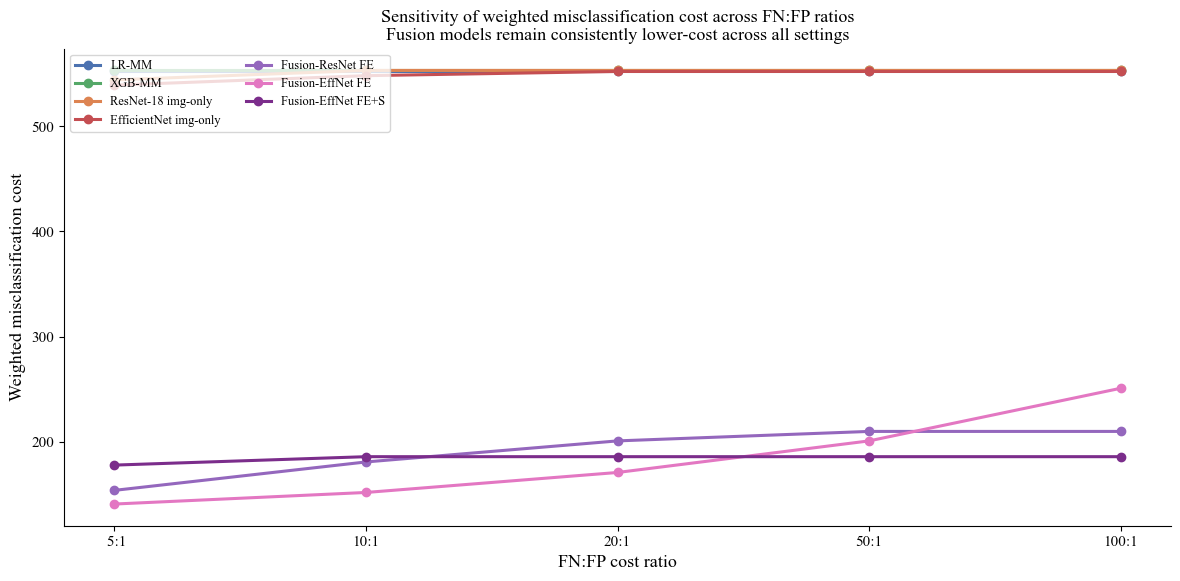

In [6]:
ratio_labels = list(ALL_SCENARIOS.keys())

fig, ax = plt.subplots(figsize=(12, 6))
for model_name in sens_df["model"].unique():
    df_m  = sens_df[sens_df["model"] == model_name]
    costs = [df_m[df_m["ratio"] == r]["weighted_cost"].values[0]
             if r in df_m["ratio"].values else np.nan
             for r in ratio_labels]
    ax.plot(range(len(ratio_labels)), costs,
            marker="o", lw=2.2, markersize=6,
            color=COLOURS.get(model_name, "#888"),
            label=model_name)

ax.set_xticks(range(len(ratio_labels)))
ax.set_xticklabels(ratio_labels, fontsize=11)
ax.set_xlabel("FN:FP cost ratio")
ax.set_ylabel("Weighted misclassification cost")
ax.set_title("Sensitivity of weighted misclassification cost across FN:FP ratios\nFusion models remain consistently lower-cost across all settings")
ax.legend(fontsize=9, loc="upper left", ncol=2)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "sensitivity_line_plot.png", dpi=150, bbox_inches="tight")
plt.show()


### Figure — Collapse matrix

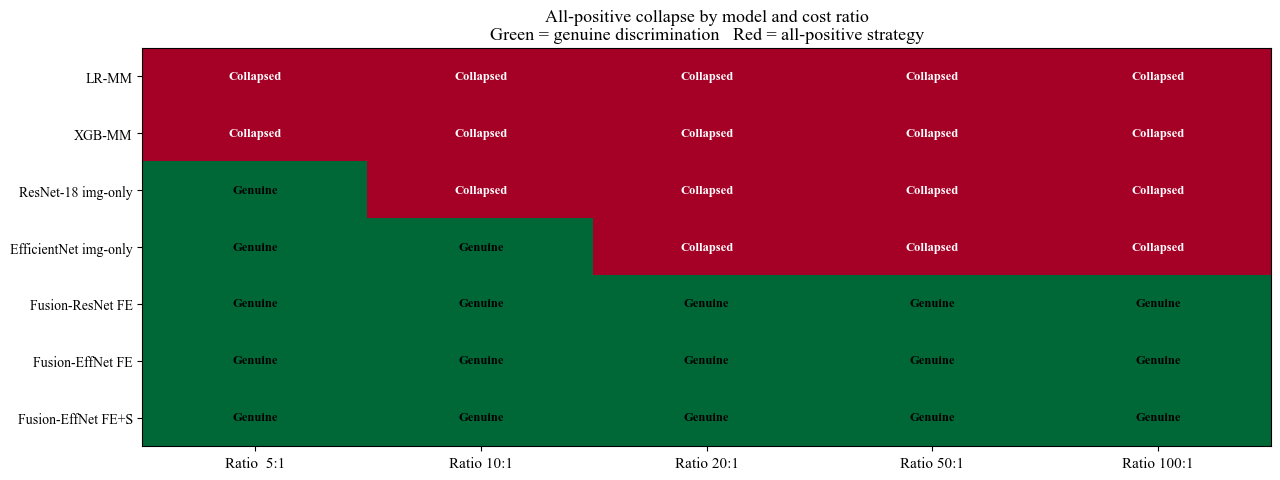

In [7]:
models_list = list(model_paths.keys())
fig, ax = plt.subplots(figsize=(13, 5))

collapse_matrix = np.zeros((len(models_list), len(ratio_labels)))
for i, m in enumerate(models_list):
    for j, r in enumerate(ratio_labels):
        row = sens_df[(sens_df["model"]==m) & (sens_df["ratio"]==r)]
        if not row.empty:
            collapse_matrix[i, j] = 1 if row.iloc[0]["collapsed"] else 0

ax.imshow(collapse_matrix, cmap="RdYlGn_r", vmin=0, vmax=1, aspect="auto")
for i in range(len(models_list)):
    for j in range(len(ratio_labels)):
        val = collapse_matrix[i, j]
        ax.text(j, i, "Collapsed" if val == 1 else "Genuine",
                ha="center", va="center", fontsize=9,
                color="white" if val == 1 else "black",
                fontweight="bold")

ax.set_xticks(range(len(ratio_labels)))
ax.set_xticklabels(["Ratio " + r for r in ratio_labels], fontsize=11)
ax.set_yticks(range(len(models_list)))
ax.set_yticklabels(models_list, fontsize=10)
ax.set_title("All-positive collapse by model and cost ratio\nGreen = genuine discrimination   Red = all-positive strategy")
fig.tight_layout()
fig.savefig(FIG_DIR / "sensitivity_collapse_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Section 2 — Final comparison at 10:1


### Table 2 — Best per family at 10:1

In [8]:
df_main = sens_df[sens_df["ratio"] == COST_SCENARIO].copy()

unimodal_mask = ~df_main["model"].str.startswith("Fusion")
baseline_cost = df_main[unimodal_mask]["weighted_cost"].min()

df_main["Reduction (%)"] = (
    (baseline_cost - df_main["weighted_cost"]) / baseline_cost * 100
).round(1)

t2 = df_main[["model","threshold","precision","recall","f1",
               "tn","fp","fn","weighted_cost","Reduction (%)","collapsed"]
            ].sort_values("weighted_cost").reset_index(drop=True)
t2.columns = ["Model","Threshold","Precision","Recall","F1",
               "TN","FP","FN","Weighted cost","Reduction (%)","Collapsed"]
t2["Precision"] = t2["Precision"].round(4)
t2["Recall"]    = t2["Recall"].round(4)
t2["F1"]        = t2["F1"].round(4)

print("="*100)
print("TABLE 2 — Final comparison at " + COST_SCENARIO)
print("Best unimodal baseline weighted cost: " + str(int(baseline_cost)))
print("="*100)
print(t2.to_string(index=False))
t2.to_csv(FIG_DIR / "table2_comparison_10_1.csv", index=False)


TABLE 2 — Final comparison at 10:1
Best unimodal baseline weighted cost: 548
                Model  Threshold  Precision  Recall     F1  TN  FP  FN  Weighted cost  Reduction (%)  Collapsed
     Fusion-EffNet FE       0.13     0.8743  0.9978 0.9320 422 132   2            152           72.3      False
     Fusion-ResNet FE       0.12     0.8748  0.9946 0.9308 423 131   5            181           67.0      False
   Fusion-EffNet FE+S       0.11     0.8318  1.0000 0.9082 368 186   0            186           66.1      False
EfficientNet img-only       0.25     0.6307  0.9989 0.7732  16 538   1            548            0.0      False
                LR-MM       0.18     0.6250  1.0000 0.7692   2 552   0            552           -0.7       True
               XGB-MM       0.14     0.6246  1.0000 0.7689   1 553   0            553           -0.9       True
   ResNet-18 img-only       0.12     0.6246  1.0000 0.7689   1 553   0            553           -0.9       True


### Figure — Bar chart: weighted cost at 10:1

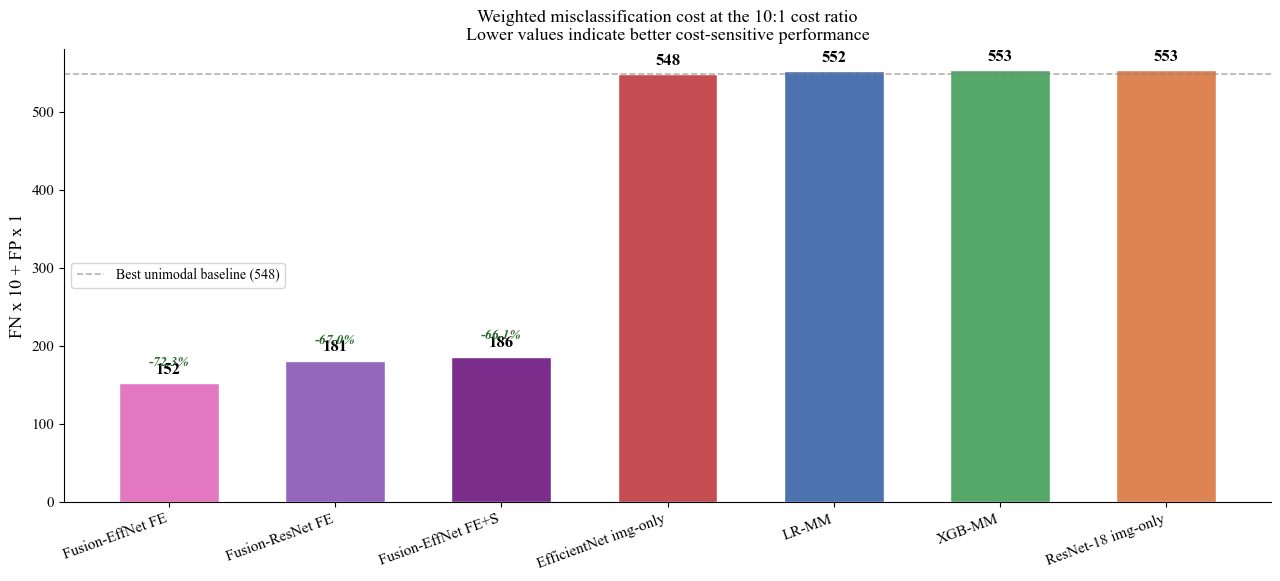

In [9]:
fig, ax = plt.subplots(figsize=(13, 6))
clrs  = [COLOURS.get(m, "#888") for m in t2["Model"]]
bars  = ax.bar(range(len(t2)), t2["Weighted cost"],
               color=clrs, edgecolor="white", width=0.6)
ax.bar_label(bars, labels=[str(v) for v in t2["Weighted cost"]],
             padding=4, fontsize=12, fontweight="bold")

for i, row in t2.iterrows():
    if row["Model"].startswith("Fusion") and row["Reduction (%)"] > 0:
        ax.text(i, row["Weighted cost"] + max(t2["Weighted cost"]) * 0.04,
                "-" + str(row["Reduction (%)"]) + "%",
                ha="center", fontsize=10, color="#2d6a2d",
                fontweight="bold", style="italic")

ax.set_xticks(range(len(t2)))
ax.set_xticklabels(t2["Model"], rotation=20, ha="right", fontsize=11)
ax.set_ylabel("FN x " + str(FN_WEIGHT) + " + FP x " + str(FP_WEIGHT))
ax.set_title("Weighted misclassification cost at the " + COST_SCENARIO +
             " cost ratio\nLower values indicate better cost-sensitive performance")
ax.axhline(int(baseline_cost), color="gray", linestyle="--", lw=1.2,
           alpha=0.6, label="Best unimodal baseline (" +
           str(int(baseline_cost)) + ")")
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_weighted_cost_10_1.png", dpi=150, bbox_inches="tight")
plt.show()


### Figure — Confusion matrices at 10:1

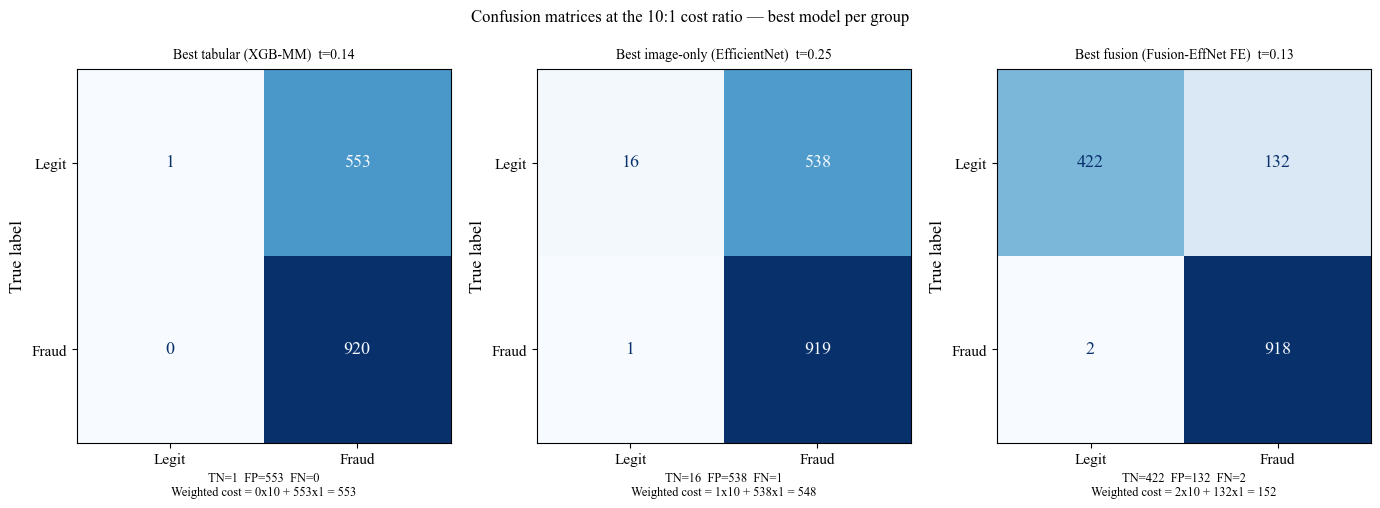

In [10]:
cm_models = {
    "Best tabular (XGB-MM)":           ("XGB-MM",
                                        R_NB/"mm_tabular_xgboost"/"B_smote"),
    "Best image-only (EfficientNet)":  ("EfficientNet img-only",
                                        R_NB/"mm_image_efficientnet_b0"/"B_sampler"),
    "Best fusion (Fusion-EffNet FE)":  ("Fusion-EffNet FE",
                                        R_NB/"mm_deep_efficientnet_b0"/"C_fe_normal"),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (panel_title, (model_name, folder)) in zip(axes, cm_models.items()):
    row = df_main[df_main["model"] == model_name]
    if row.empty:
        ax.axis("off")
        continue
    t = float(row.iloc[0]["threshold"])

    try:
        pred_df = pd.read_csv(folder / "test_predictions.csv")
    except FileNotFoundError:
        ax.axis("off")
        continue

    yt     = pred_df["y_true"].values
    yp     = pred_df["y_prob"].values
    y_pred = (yp >= t).astype(int)
    cm     = confusion_matrix(yt, y_pred, labels=[0, 1])
    tn, fp, fn, tp_ = cm.ravel()
    wc = fn * FN_WEIGHT + fp * FP_WEIGHT

    ConfusionMatrixDisplay(cm, display_labels=["Legit","Fraud"]).plot(
        ax=ax, colorbar=False, values_format="d", cmap="Blues")
    ax.set_title(panel_title + "  t=" + str(t), fontsize=10, pad=8)
    xlabel = ("TN=" + str(tn) + "  FP=" + str(fp) + "  FN=" + str(fn) + "\n" +
                "Weighted cost = " + str(fn) + "x" + str(FN_WEIGHT) +
                " + " + str(fp) + "x" + str(FP_WEIGHT) + " = " + str(wc))
    ax.set_xlabel(xlabel, fontsize=9)

fig.suptitle("Confusion matrices at the " + COST_SCENARIO +
             " cost ratio — best model per group", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_confusion_matrices_10_1.png",
            dpi=150, bbox_inches="tight")
plt.show()


---
## Section 3 — Feasibility analysis

Weighted cost alone does not guarantee operational feasibility.
A model with low cost but 550 false alarms is impractical.

**Three views:**
- Option A: Feasibility table at 10:1 operating point
- Option B: Shared FP budget — which model catches most fraud given FP ≤ 200?
- Option C: Shared recall target — which model has fewest FP given recall ≥ 0.99?


### Option A — Feasibility table at 10:1

In [11]:
feasibility_rows = []
for name, scan in all_scans.items():
    best = best_at_ratio(scan)
    feasibility_rows.append({
        "Model":         name,
        "Threshold":     best["threshold"],
        "TN":            int(best["tn"]),
        "FP":            int(best["fp"]),
        "FN":            int(best["fn"]),
        "TP":            int(best["tp"]),
        "Precision":     round(best["precision"], 4),
        "Recall":        round(best["recall"],    4),
        "FPR (%)":       round(best["fpr"] * 100, 1),
        "Alert volume":  int(best["alerts"]),
        "Weighted cost": int(best["weighted_cost"]),
        "Collapsed":     int(best["tn"]) <= 5,
    })

feasibility_df = pd.DataFrame(feasibility_rows).sort_values("Weighted cost")
unimodal_mask  = ~feasibility_df["Model"].str.startswith("Fusion")
baseline_cost  = feasibility_df[unimodal_mask]["Weighted cost"].min()
feasibility_df["Reduction (%)"] = (
    (baseline_cost - feasibility_df["Weighted cost"]) / baseline_cost * 100
).round(1)

print("="*100)
print("FEASIBILITY TABLE — " + COST_SCENARIO +
      "  (FN x " + str(FN_WEIGHT) + " + FP x " + str(FP_WEIGHT) + ")")
print("="*100)
print(feasibility_df.to_string(index=False))
feasibility_df.to_csv(FIG_DIR / "feasibility_table_10_1.csv", index=False)


FEASIBILITY TABLE — 10:1  (FN x 10 + FP x 1)
                Model  Threshold  TN  FP  FN  TP  Precision  Recall  FPR (%)  Alert volume  Weighted cost  Collapsed  Reduction (%)
     Fusion-EffNet FE       0.13 422 132   2 918     0.8743  0.9978     23.8          1050            152      False           72.3
     Fusion-ResNet FE       0.12 423 131   5 915     0.8748  0.9946     23.6          1046            181      False           67.0
   Fusion-EffNet FE+S       0.11 368 186   0 920     0.8318  1.0000     33.6          1106            186      False           66.1
EfficientNet img-only       0.25  16 538   1 919     0.6307  0.9989     97.1          1457            548      False            0.0
                LR-MM       0.18   2 552   0 920     0.6250  1.0000     99.6          1472            552       True           -0.7
               XGB-MM       0.14   1 553   0 920     0.6246  1.0000     99.8          1473            553       True           -0.9
   ResNet-18 img-only       0.1

### Figure — FP vs Recall scatter

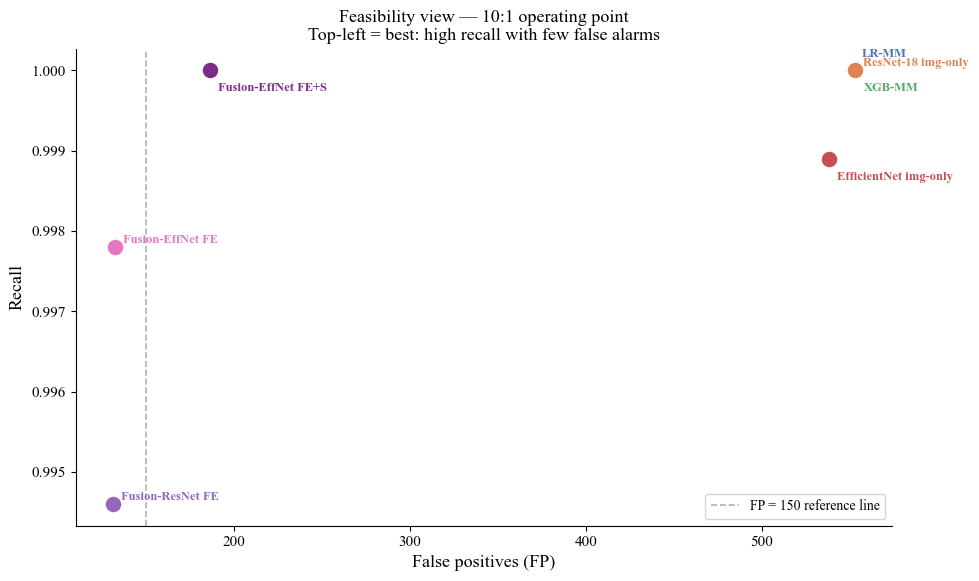

In [12]:
label_offsets = {
    "LR-MM":                ( 6,  10),
    "XGB-MM":               ( 6, -15),
    "ResNet-18 img-only":   ( 6,   3),
    "EfficientNet img-only":( 6, -15),
    "Fusion-ResNet FE":     ( 6,   3),
    "Fusion-EffNet FE":     ( 6,   3),
    "Fusion-EffNet FE+S":   ( 6, -15),
}

fig, ax = plt.subplots(figsize=(10, 6))
for _, row in feasibility_df.iterrows():
    c  = COLOURS.get(row["Model"], "#888")
    ox, oy = label_offsets.get(row["Model"], (6, 3))
    ax.scatter(row["FP"], row["Recall"], s=160, color=c,
               zorder=5, edgecolors="white", linewidth=1.5)
    ax.annotate(row["Model"],
                xy=(row["FP"], row["Recall"]),
                xytext=(ox, oy), textcoords="offset points",
                fontsize=9, color=c, fontweight="bold")

ax.axvline(150, color="gray", linestyle="--", lw=1.2, alpha=0.6,
           label="FP = 150 reference line")
ax.set_xlabel("False positives (FP)")
ax.set_ylabel("Recall")
ax.set_title("Feasibility view — " + COST_SCENARIO + " operating point\nTop-left = best: high recall with few false alarms")
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "feasibility_fp_vs_recall.png",
            dpi=150, bbox_inches="tight")
plt.show()


### Figure — Alert volume

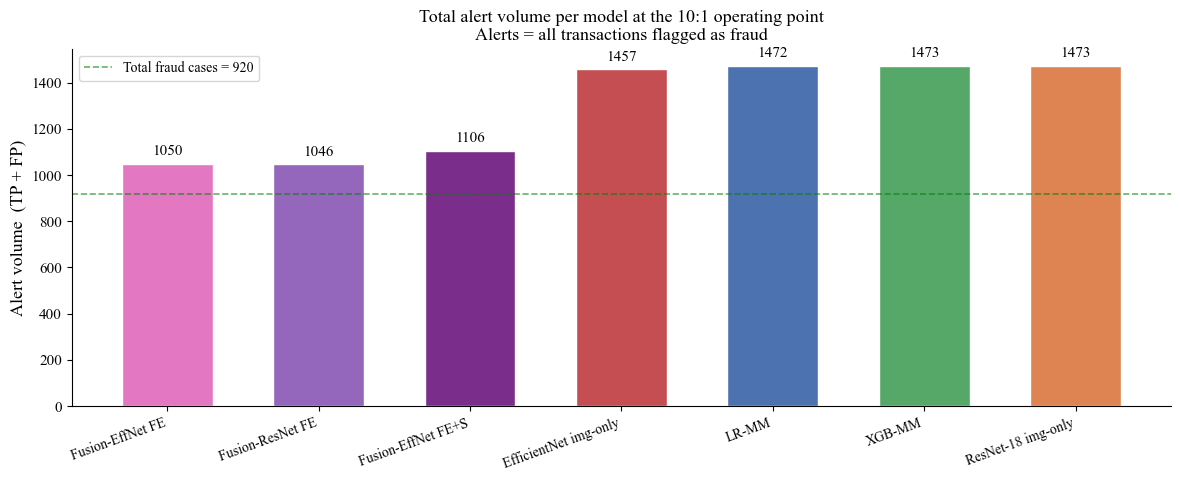

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
clrs = [COLOURS.get(m,"#888") for m in feasibility_df["Model"]]
bars = ax.bar(range(len(feasibility_df)), feasibility_df["Alert volume"],
              color=clrs, edgecolor="white", width=0.6)
ax.bar_label(bars, labels=[str(v) for v in feasibility_df["Alert volume"]],
             padding=4, fontsize=11)
ax.set_xticks(range(len(feasibility_df)))
ax.set_xticklabels(feasibility_df["Model"], rotation=20,
                   ha="right", fontsize=10)
ax.set_ylabel("Alert volume  (TP + FP)")
ax.set_title("Total alert volume per model at the " + COST_SCENARIO +
             " operating point\nAlerts = all transactions flagged as fraud")
ax.axhline(N_FRAUD, color="green", linestyle="--", lw=1.2, alpha=0.6,
           label="Total fraud cases = " + str(N_FRAUD))
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "feasibility_alert_volume.png",
            dpi=150, bbox_inches="tight")
plt.show()


### Option B — Shared FP budget (FP ≤ 200)

In [14]:
FP_BUDGET = 200

budget_rows = []
for name, scan in all_scans.items():
    feasible = scan[scan["fp"] <= FP_BUDGET].copy()
    if feasible.empty:
        budget_rows.append({
            "Model": name,
            "Note":  "Cannot reach FP <= " + str(FP_BUDGET),
            "Threshold": None, "FP": None, "FN": None, "TP": None,
            "Precision": None, "Recall": None,
            "Alert volume": None, "Weighted cost": None,
        })
        continue
    best = feasible.sort_values(
        ["recall","precision"], ascending=[False, False]).iloc[0]
    budget_rows.append({
        "Model":         name,
        "Note":          "feasible",
        "Threshold":     best["threshold"],
        "FP":            int(best["fp"]),
        "FN":            int(best["fn"]),
        "TP":            int(best["tp"]),
        "Precision":     round(best["precision"], 4),
        "Recall":        round(best["recall"],    4),
        "Alert volume":  int(best["alerts"]),
        "Weighted cost": int(best["weighted_cost"]),
    })

budget_df = pd.DataFrame(budget_rows).sort_values(
    "Recall", ascending=False, na_position="last")

print("="*85)
print("OPTION B — Shared FP budget: FP <= " + str(FP_BUDGET))
print("="*85)
print(budget_df.to_string(index=False))
budget_df.to_csv(FIG_DIR / ("feasibility_fp_budget_" + str(FP_BUDGET) + ".csv"),
                 index=False)


OPTION B — Shared FP budget: FP <= 200
                Model     Note  Threshold  FP  FN  TP  Precision  Recall  Alert volume  Weighted cost
   Fusion-EffNet FE+S feasible       0.11 186   0 920     0.8318  1.0000          1106            186
     Fusion-ResNet FE feasible       0.08 181   1 919     0.8355  0.9989          1100            191
     Fusion-EffNet FE feasible       0.10 151   1 919     0.8589  0.9989          1070            161
EfficientNet img-only feasible       0.41 196 114 806     0.8044  0.8761          1002           1336
   ResNet-18 img-only feasible       0.39 188 125 795     0.8087  0.8641           983           1438
               XGB-MM feasible       0.33 183 223 697     0.7920  0.7576           880           2413
                LR-MM feasible       0.55 197 251 669     0.7725  0.7272           866           2707


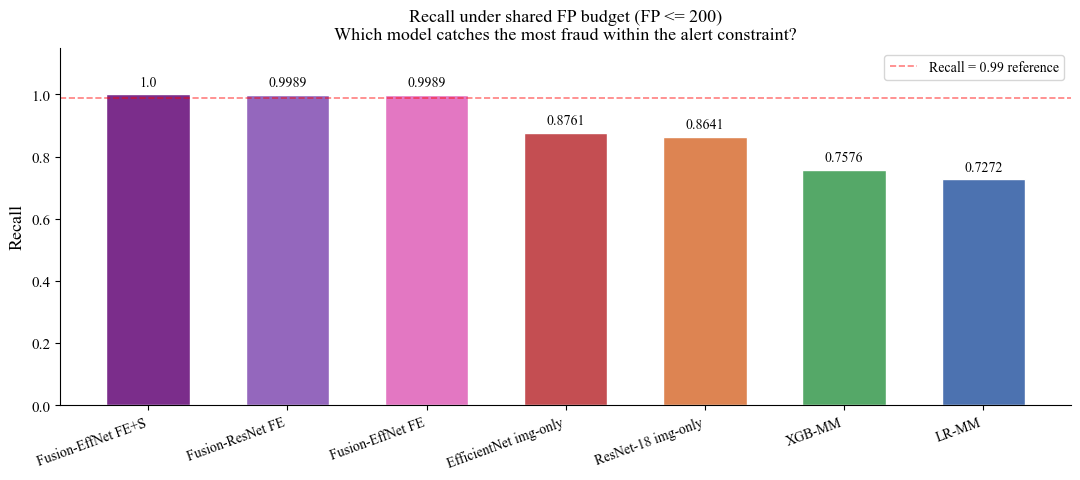

In [15]:
valid = budget_df.dropna(subset=["Recall"])
fig, ax = plt.subplots(figsize=(11, 5))
clrs_b = [COLOURS.get(m,"#888") for m in valid["Model"]]
bars = ax.bar(range(len(valid)), valid["Recall"],
              color=clrs_b, edgecolor="white", width=0.6)
ax.bar_label(bars, labels=[str(round(v, 4)) for v in valid["Recall"]],
             padding=4, fontsize=10)
ax.set_xticks(range(len(valid)))
ax.set_xticklabels(valid["Model"], rotation=20, ha="right", fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Recall")
ax.set_title("Recall under shared FP budget (FP <= " + str(FP_BUDGET) + ")\nWhich model catches the most fraud within the alert constraint?")
ax.axhline(0.99, color="red", linestyle="--", lw=1.2, alpha=0.5,
           label="Recall = 0.99 reference")
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "feasibility_fp_budget_recall.png",
            dpi=150, bbox_inches="tight")
plt.show()


### Option C — Shared recall target (recall ≥ 0.99)

In [16]:
RECALL_TARGET = 0.99

recall_rows = []
for name, scan in all_scans.items():
    feasible = scan[scan["recall"] >= RECALL_TARGET].copy()
    if feasible.empty:
        recall_rows.append({
            "Model": name,
            "Note":  "Cannot reach recall >= " + str(RECALL_TARGET),
            "Threshold": None, "FP": None, "FN": None, "TP": None,
            "Precision": None, "Recall": None,
            "Alert volume": None, "Weighted cost": None,
        })
        continue
    best = feasible.sort_values(
        ["fp","precision"], ascending=[True, False]).iloc[0]
    recall_rows.append({
        "Model":         name,
        "Note":          "feasible",
        "Threshold":     best["threshold"],
        "FP":            int(best["fp"]),
        "FN":            int(best["fn"]),
        "TP":            int(best["tp"]),
        "Precision":     round(best["precision"], 4),
        "Recall":        round(best["recall"],    4),
        "Alert volume":  int(best["alerts"]),
        "Weighted cost": int(best["weighted_cost"]),
    })

recall_df = pd.DataFrame(recall_rows).sort_values(
    "FP", ascending=True, na_position="last")

print("="*85)
print("OPTION C — Shared recall target: recall >= " + str(RECALL_TARGET))
print("Which model creates fewest false alarms while catching >= 99% of fraud?")
print("="*85)
print(recall_df.to_string(index=False))
recall_df.to_csv(FIG_DIR / ("feasibility_recall_" + str(RECALL_TARGET) + ".csv"),
                 index=False)


OPTION C — Shared recall target: recall >= 0.99
Which model creates fewest false alarms while catching >= 99% of fraud?
                Model     Note  Threshold  FP  FN  TP  Precision  Recall  Alert volume  Weighted cost
     Fusion-EffNet FE feasible       0.19 114   8 912     0.8889  0.9913          1026            194
     Fusion-ResNet FE feasible       0.14 124   6 914     0.8805  0.9935          1038            184
   Fusion-EffNet FE+S feasible       0.20 144   8 912     0.8636  0.9913          1056            224
EfficientNet img-only feasible       0.28 509   7 913     0.6421  0.9924          1422            579
   ResNet-18 img-only feasible       0.23 520   6 914     0.6374  0.9935          1434            580
                LR-MM feasible       0.33 532   9 911     0.6313  0.9902          1443            622
               XGB-MM feasible       0.22 541   6 914     0.6282  0.9935          1455            601


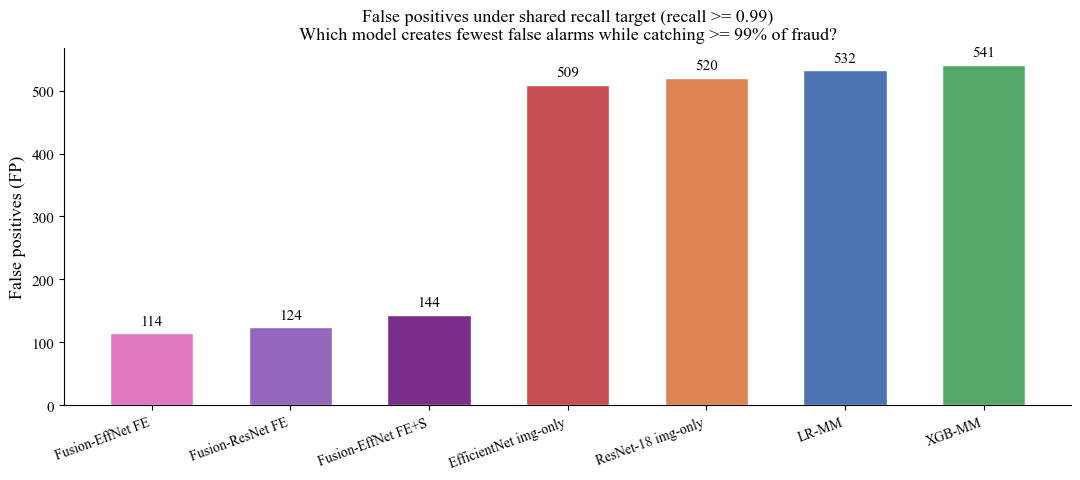

In [17]:
valid_r = recall_df.dropna(subset=["FP"])
fig, ax = plt.subplots(figsize=(11, 5))
clrs_r = [COLOURS.get(m,"#888") for m in valid_r["Model"]]
bars = ax.bar(range(len(valid_r)), valid_r["FP"],
              color=clrs_r, edgecolor="white", width=0.6)
ax.bar_label(bars, labels=[str(v) for v in valid_r["FP"]],
             padding=4, fontsize=11)
ax.set_xticks(range(len(valid_r)))
ax.set_xticklabels(valid_r["Model"], rotation=20, ha="right", fontsize=10)
ax.set_ylabel("False positives (FP)")
ax.set_title("False positives under shared recall target (recall >= " +
             str(RECALL_TARGET) + ")\nWhich model creates fewest false alarms while catching >= 99% of fraud?")
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "feasibility_recall_target_fp.png",
            dpi=150, bbox_inches="tight")
plt.show()


---
## Summary

In [18]:
best_fusion = feasibility_df[
    feasibility_df["Model"].str.startswith("Fusion")].iloc[0]
best_uni    = feasibility_df[
    ~feasibility_df["Model"].str.startswith("Fusion")].iloc[0]

fp_red   = (best_uni["FP"] - best_fusion["FP"]) / max(best_uni["FP"],1)*100
cost_red = best_fusion["Reduction (%)"]

print("="*70)
print("KEY RESULTS FOR THESIS")
print("="*70)
print()
print("At the " + COST_SCENARIO + " operating point:")
print("  Best unimodal : " + best_uni["Model"] +
      "  cost=" + str(best_uni["Weighted cost"]) +
      "  FP=" + str(best_uni["FP"]) +
      "  FPR=" + str(best_uni["FPR (%)"]) + "%")
print("  Best fusion   : " + best_fusion["Model"] +
      "  cost=" + str(best_fusion["Weighted cost"]) +
      "  FP=" + str(best_fusion["FP"]) +
      "  FPR=" + str(best_fusion["FPR (%)"]) + "%")
print()
print("  Cost reduction : " + str(cost_red) + "%")
print("  FP reduction   : " + str(round(fp_red, 0)) + "%" +
      "  (" + str(best_uni["FP"]) + " -> " + str(best_fusion["FP"]) + ")")
print()
print("Thesis sentence:")
print("-"*70)
print(
    "At the " + COST_SCENARIO + " operating point, the best fusion model (" +
    best_fusion["Model"] + ") achieved a weighted misclassification cost of " +
    str(best_fusion["Weighted cost"]) + ", compared with " +
    str(best_uni["Weighted cost"]) + " for the best unimodal baseline (" +
    best_uni["Model"] + "), a " + str(cost_red) + "% reduction. " +
    "The fusion model also generated substantially fewer false alarms (" +
    str(best_fusion["FP"]) + " versus " + str(best_uni["FP"]) + "), " +
    "a " + str(round(fp_red, 0)) + "% reduction in false-positive burden " +
    "at comparable recall levels."
)


KEY RESULTS FOR THESIS

At the 10:1 operating point:
  Best unimodal : EfficientNet img-only  cost=548  FP=538  FPR=97.1%
  Best fusion   : Fusion-EffNet FE  cost=152  FP=132  FPR=23.8%

  Cost reduction : 72.3%
  FP reduction   : 75.0%  (538 -> 132)

Thesis sentence:
----------------------------------------------------------------------
At the 10:1 operating point, the best fusion model (Fusion-EffNet FE) achieved a weighted misclassification cost of 152, compared with 548 for the best unimodal baseline (EfficientNet img-only), a 72.3% reduction. The fusion model also generated substantially fewer false alarms (132 versus 538), a 75.0% reduction in false-positive burden at comparable recall levels.
